This notebook provides some examples on two-qubit tomography. 

## Initialization

### Imports

First, we'll do the meeded imports. Note that library's .py files are directly accessed from the folder `solver`.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
print(sys.executable)

/Users/ivansemenov/monitoring-system/.venv/bin/python3


In [3]:
from os import path
import warnings
assert path.exists("solver") 
assert path.exists("solver/utils")

In [4]:
#!pip3 install -r requirements.txt

In [5]:
with warnings.catch_warnings():  # warning still somehow pierces through, so I cleared the cell output
    import tensorflow as tf  # tf 2.x
    import tensornetwork as tn
    tn.set_default_backend("tensorflow")
    
import numpy as np
import QGOpt as qgo
import math
import matplotlib.pyplot as plt

import solver.utils.general_utils as util
import solver.noising_tools as ns
import solver.utils.channel_utils as c_util
import solver.file_management as fm
import solver.circuits_generation as cg

from solver.QCCalc import QCEvaluator
from solver.experiments import ExperimentConductor, assert_psi2_eq_1
from solver.utils.misc import unwrap_dict, NconTemplate, INT, FLOAT, COMPLEX, ID_GATE
from solver.QCSolver import QGOptSolver, get_complex_channel_form, QGOptSolverDebug

/Users/ivansemenov/monitoring-system/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [6]:
import json
import re
import os
from collections import defaultdict

In [7]:
# Replaces the legacy parser above.  Labels are global identities of (gate type, angle), never local indices.
import hashlib

PARAMETERIZED_GATES = {'rx': 'Rx', 'ry': 'Ry', 'rz': 'Rz', 'rxx': 'Rxx'}

def parameterized_gate_label(raw_type: str, angle: float) -> str:
    digest = hashlib.sha256(f'{raw_type}:{float(angle).hex()}'.encode()).hexdigest()[:16]
    return f'{PARAMETERIZED_GATES[raw_type]}-h{digest}'

def parse_qasm_gates(qasm_content: str) -> tuple[list[str], dict[str, tuple[str, float]]]:
    """Parse supported QASM operations without silently substituting identities.

    Terminal measurements are intentionally omitted: the evaluator already projects
    computational-basis outcomes.  Readout error is not identified under this model.
    """
    gates, parameter_map = [], {}
    for line_number, raw_line in enumerate(qasm_content.splitlines(), start=1):
        line = raw_line.split('//', 1)[0].strip().rstrip(';').strip()
        if not line or line.startswith(('OPENQASM', 'include', 'qreg', 'creg', 'barrier')):
            continue
        if line.startswith('measure'):
            continue
        match = re.fullmatch(r'([A-Za-z][A-Za-z0-9_]*)\(([^)]+)\)\s+(.+)', line)
        if match is None:
            raise ValueError(f'Unsupported QASM statement at line {line_number}: {raw_line}')
        raw_type, angle_text, operands = match.groups()
        raw_type = raw_type.lower()
        if raw_type not in PARAMETERIZED_GATES:
            raise ValueError(f'Unsupported QASM gate {raw_type!r} at line {line_number}')
        indices = re.findall(r'q\[(\d+)\]', operands)
        expected_arity = 2 if raw_type == 'rxx' else 1
        if len(indices) != expected_arity:
            raise ValueError(f'Wrong arity for {raw_type} at line {line_number}')
        try:
            angle = float(angle_text)
        except ValueError as exc:
            raise ValueError(f'Non-numeric angle {angle_text!r} at line {line_number}') from exc
        label = parameterized_gate_label(raw_type, angle)
        parameter_map[label] = (raw_type, angle)
        gates.append(f"{label}_{'_'.join(indices)}")
    return gates, parameter_map

def enrich_json_with_gates(json_path: str, qasm_dir=None) -> list[dict]:
    with open(json_path, encoding='utf-8') as handle:
        data = json.load(handle)
    qasm_dir = qasm_dir or os.path.dirname(json_path)
    for entry in data:
        qasm_path = os.path.join(qasm_dir, entry['fname'])
        if not os.path.isfile(qasm_path):
            raise FileNotFoundError(qasm_path)
        with open(qasm_path, encoding='utf-8') as handle:
            entry['gates'], entry['param_map'] = parse_qasm_gates(handle.read())
    return data

In [8]:
DEPTHS = (1, 3, 5, 7, 9)
DATA_ROOT = 'ionQuantum_exp_data_article/zne_ionQ'
enriched_data = []
for depth in DEPTHS:
    enriched_data.extend(enrich_json_with_gates(
        f'{DATA_ROOT}/depth_{depth}_1_results.json', f'{DATA_ROOT}/depth_{depth}'))

assert len(enriched_data) == 240
with open('enriched_results.json', 'w', encoding='utf-8') as handle:
    json.dump(enriched_data, handle, indent=2)
print(f'Loaded {len(enriched_data)} result circuits across depths {DEPTHS}.')

Loaded 240 result circuits across depths (1, 3, 5, 7, 9).


In [9]:
cur_data = enriched_data[0]

In [10]:
cur_data

{'fname': 'circuit_d1_r0_s1.qasm',
 'shots': 2048,
 'result': {'0000': 1736,
  '0001': 37,
  '0010': 37,
  '0011': 34,
  '0100': 99,
  '0110': 1,
  '0111': 4,
  '1000': 87,
  '1001': 1,
  '1010': 3,
  '1011': 4,
  '1100': 4,
  '1101': 1},
 'gates': ['Ry-hd3865987a148be1b_0',
  'Rx-h17a738bd3143e977_1',
  'Rx-h5e7ebe41c3eb4b82_2',
  'Rz-h46426aadecbf3f3e_3',
  'Rxx-h5b4c73ceaa9b3614_1_2',
  'Rxx-ha82c63bb02a06e29_0_3',
  'Rxx-h8e496f7c0766e2c7_0_3',
  'Rxx-h2ceb4c79c20c4411_1_2',
  'Rz-h642ab06ee15943ee_3',
  'Rx-h577abd891a9ee55f_2',
  'Rx-hdebe552f90807378_1',
  'Ry-h35190cefa904713f_0'],
 'param_map': {'Ry-hd3865987a148be1b': ('ry', -0.3002758371461556),
  'Rx-h17a738bd3143e977': ('rx', 2.739336647310277),
  'Rx-h5e7ebe41c3eb4b82': ('rx', 0.8168095568404232),
  'Rz-h46426aadecbf3f3e': ('rz', -0.18388033583457286),
  'Rxx-h5b4c73ceaa9b3614': ('rxx', -0.7097846736474587),
  'Rxx-ha82c63bb02a06e29': ('rxx', -2.9481143892199015),
  'Rxx-h8e496f7c0766e2c7': ('rxx', 2.9481143892199015),
  

In [11]:
enriched_data[1]

{'fname': 'circuit_d1_r0_s3.qasm',
 'shots': 2048,
 'result': {'0000': 1124,
  '0001': 39,
  '0010': 58,
  '0011': 77,
  '0100': 291,
  '0101': 10,
  '0110': 11,
  '0111': 20,
  '1000': 251,
  '1001': 17,
  '1010': 11,
  '1011': 17,
  '1100': 109,
  '1101': 4,
  '1110': 3,
  '1111': 6},
 'gates': ['Ry-hd3865987a148be1b_0',
  'Rx-h17a738bd3143e977_1',
  'Rx-h5e7ebe41c3eb4b82_2',
  'Rz-h46426aadecbf3f3e_3',
  'Rxx-h5b4c73ceaa9b3614_1_2',
  'Rxx-ha82c63bb02a06e29_0_3',
  'Rxx-h8e496f7c0766e2c7_0_3',
  'Rxx-h2ceb4c79c20c4411_1_2',
  'Rz-h642ab06ee15943ee_3',
  'Rx-h577abd891a9ee55f_2',
  'Rx-hdebe552f90807378_1',
  'Ry-h35190cefa904713f_0',
  'Ry-hd3865987a148be1b_0',
  'Rx-h17a738bd3143e977_1',
  'Rx-h5e7ebe41c3eb4b82_2',
  'Rz-h46426aadecbf3f3e_3',
  'Rxx-h5b4c73ceaa9b3614_1_2',
  'Rxx-ha82c63bb02a06e29_0_3',
  'Rxx-h8e496f7c0766e2c7_0_3',
  'Rxx-h2ceb4c79c20c4411_1_2',
  'Rz-h642ab06ee15943ee_3',
  'Rx-h577abd891a9ee55f_2',
  'Rx-hdebe552f90807378_1',
  'Ry-h35190cefa904713f_0',
  'Ry-h

In [13]:
def create_unitary_rotation_xx(angle: float) -> tf.Tensor:
    """
    Создаёт унитарный оператор, описывающий вращение по оси XX (вентиль Rxx).
    Матрица размера 4×4 в базисе |00>, |01>, |10>, |11>.

    Формула: Rxx(θ) = exp(-i θ/2 * X⊗X)

    Матрица:
    [ cos(θ/2)    0         0        -i·sin(θ/2) ]
    [ 0           cos(θ/2)  -i·sin(θ/2)  0       ]
    [ 0           -i·sin(θ/2) cos(θ/2)  0       ]
    [ -i·sin(θ/2) 0         0         cos(θ/2)  ]
    """
    half = angle / 2.0
    cos_h = tf.cos(half)
    sin_h = tf.sin(half)

    dtype = COMPLEX
    c = tf.cast(cos_h, dtype)
    s_neg = tf.cast(-1j, dtype) * tf.cast(sin_h, dtype)
    zero = tf.cast(0.0, dtype)

    # Строки матрицы
    row0 = tf.stack([c,    zero, zero, s_neg])
    row1 = tf.stack([zero, c,    s_neg, zero])
    row2 = tf.stack([zero, s_neg, c,    zero])
    row3 = tf.stack([s_neg, zero, zero, c])

    return tf.stack([row0, row1, row2, row3])

In [14]:
dim=2

In [15]:
def channel_for_gate(raw_type: str, angle: float) -> tf.Tensor:
    """Build the ideal channel for a supported QASM gate type."""
    if raw_type == 'rx':
        return c_util.convert_1qmatrix_to_channel(util.create_unitary_rotation_x(angle))
    if raw_type == 'ry':
        return c_util.convert_1qmatrix_to_channel(util.create_unitary_rotation_y(angle))
    if raw_type == 'rz':
        return c_util.convert_1qmatrix_to_channel(util.create_unitary_rotation_z(angle))
    if raw_type == 'rxx':
        unitary = util.convert_44_to_2222(create_unitary_rotation_xx(angle))
        return c_util.convert_2qmatrix_to_channel(unitary)
    raise ValueError(f'Unsupported gate type {raw_type!r}')


def _assemble_gate_dict(parameter_map: dict[str, tuple[str, float]]) -> tuple[dict, int, int]:
    """Build ordered gate dict from label -> (raw_type, angle) mapping."""
    one_qubit_gates, two_qubit_gates = {}, {}
    for label, (raw_type, angle) in sorted(parameter_map.items()):
        channel = channel_for_gate(raw_type, angle)
        (two_qubit_gates if raw_type == 'rxx' else one_qubit_gates)[label] = channel

    one_qubit_gates['Noise'] = c_util.convert_1qmatrix_to_channel(tf.eye(2, dtype=COMPLEX))
    two_qubit_gates['Noise2'] = c_util.convert_2qmatrix_to_channel(util.convert_44_to_2222(tf.eye(4, dtype=COMPLEX)))
    gate_dict = {**one_qubit_gates}
    gate_dict[ID_GATE] = c_util.convert_1qmatrix_to_channel(tf.eye(2, dtype=COMPLEX))
    gate_dict.update(two_qubit_gates)
    return gate_dict, len(one_qubit_gates), len(two_qubit_gates)


def build_gate_dict(entry: dict) -> tuple[dict, int, int]:
    """Build ideal channels for one enriched entry plus shared 1q noise."""
    parameter_map = {
        label: entry['param_map'][label]
        for label in {gate.split('_')[0] for gate in entry['gates']}
    }
    return _assemble_gate_dict(parameter_map)


def build_global_gate_dict(entries: list[dict]) -> tuple[dict, int, int]:
    """Build ideal channels for all entries plus one shared learnable 1q noise channel."""
    parameter_map = {}
    for entry in entries:
        for label, specification in entry['param_map'].items():
            if label in parameter_map and parameter_map[label] != specification:
                raise ValueError(f'Conflicting definition for {label}')
            parameter_map[label] = specification
    return _assemble_gate_dict(parameter_map)

In [16]:
default_pure_channels, one_qub_num, two_qub_num = build_global_gate_dict(enriched_data)

2026-08-06 23:51:21.705719: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-08-06 23:51:21.705741: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-08-06 23:51:21.705747: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-08-06 23:51:21.705777: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-06 23:51:21.705792: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-08-06 23:51:21.710159: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-06 23:51:21.734781: I t

2026-08-06 23:51:29.426378: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-06 23:51:29.429132: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-06 23:51:29.431864: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-06 23:51:29.434195: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-06 23:51:29.436620: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-06 23:51:29.439464: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-06 23:51:29.441974: I tensorflow/core/grappler/optimizers/cust

2026-08-06 23:51:33.737720: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-06 23:51:33.743636: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-06 23:51:33.749145: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-06 23:51:33.754678: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-06 23:51:33.760100: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-06 23:51:33.765606: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-06 23:51:33.771227: I tensorflow/core/grappler/optimizers/cust

In [17]:
len(default_pure_channels.keys())

4135

### Circuits preparation

We will need a `DataGenerator`, which can (surprisingly) generate quantum circuits, and convert quantum circuits to the tensor network template form. To initialize it, we need the gates' labels, and it's quite important to pass them in the same order as stated in `default_pure_channels` **without the internal `ID_GATE`**. Some day this inconvenient feature will be fixed. 

In [18]:
NUM_QUBITS = len(list(cur_data['result'].keys())[0])

In [19]:
NUM_QUBITS

4

In [20]:
for i in range(len(enriched_data)):
    cur_data = enriched_data[i]
    if NUM_QUBITS != len(list(cur_data['result'].keys())[0]):
        print(i, len(list(cur_data['result'].keys())[0]))

In [21]:
gates_labels = list(default_pure_channels.keys())
gates_labels.remove(ID_GATE)

gen = cg.DataGenerator(qubits_num=NUM_QUBITS,
                       gates_names=gates_labels,
                       single_qub_gates_num=one_qub_num,
                       two_qub_gates_num=two_qub_num)

In [36]:
NOISE_GATE = 'Noise'
NOISE2_GATE = 'Noise2'


def split_gate(gate_str: str) -> tuple[str, list[str]]:
    """Split ``Label_idx1_idx2...`` into gate label and qubit indices."""
    label, *indices = gate_str.split('_')
    return label, indices


def is_noise_gate(gate_str: str) -> bool:
    label, _ = split_gate(gate_str)
    return label in (NOISE_GATE, NOISE2_GATE)


def is_one_qubit_gate(gate_str: str, param_map: dict = None) -> bool:
    """Return True for 1q physical gates; False for 2q gates and Noise2."""
    label, indices = split_gate(gate_str)
    if label == NOISE_GATE:
        return True
    if label == NOISE2_GATE:
        return False
    if param_map is not None and label in param_map:
        raw_type, _ = param_map[label]
        return raw_type != 'rxx'
    if len(indices) == 1:
        return True
    if len(indices) == 2:
        return False
    raise ValueError(f'Cannot determine gate arity for {gate_str!r}')


def noise_gate_for(gate_str: str, param_map: dict = None) -> str:
    """Return Noise_<indices> or Noise2_<indices> matching the physical gate.
    For tied Noise2, all instances share the same tensor ID in template converter.
    """
    _, indices = split_gate(gate_str)
    if is_one_qubit_gate(gate_str, param_map):
        suffix = '_' + '_'.join(indices) if indices else ''
        return f'{NOISE_GATE}{suffix}'
    # Keep qubit indices for circuit structure; template converter ties them
    return f'{NOISE2_GATE}_' + '_'.join(indices)


def insert_noise_gates(gates: list[str], param_map: dict = None) -> list[str]:
    """Insert Noise / Noise2 after each physical gate, preserving qubit indices."""
    chain = []
    for gate in gates:
        if is_noise_gate(gate):
            continue
        chain.append(gate)
        if not is_one_qubit_gate(gate, param_map):
            chain.append(noise_gate_for(gate, param_map))
    return chain


def extract_chains_and_results(
    entries: list[dict],
) -> tuple[list[list[str]], list[dict[str, int]]]:
    """Build noisy circuits from parsed QASM gate lists and collect shot results."""
    chains, results = [], []
    for entry in entries:
        chains.append(insert_noise_gates(entry['gates'], entry['param_map']))
        results.append(entry['result'])
    return chains, results


def circuits_to_tied_templates(
    circs: list[list[str]],
    gen: 'DataGenerator',
    tied_2q_gates: set[str] = None
) -> dict[str, NconTemplate]:
    """Convert human-readable circuits to ncon templates with tied 2q gates.

    For gates in tied_2q_gates, all instances map to the same tensor ID
    (first instance of that gate type), ignoring qubit indices.
    """
    if tied_2q_gates is None:
        tied_2q_gates = set()
    humcon_circs = cg.transform_struc_to_ncon(circs, gen.n)
    ans = {}
    for i, circ in enumerate(humcon_circs):
        tensors, net_struc, con_order, out_order = circ
        new_tensors = []
        for gate in tensors:
            gate_info = gate.split('_')
            if gate_info[0] == ID_GATE.split('_')[0]:
                new_tensor_id = len(gen.single_qub_gates) * gen.n
            elif gate_info[0] in gen.single_qub_gates:
                assert len(gate_info) == 2
                shift = gen.single_qub_gates[gate_info[0]]
                new_tensor_id = shift * gen.n + int(gate_info[1])
            elif gate_info[0] in gen.two_qub_gates:
                shift = gen.two_qub_gates[gate_info[0]]
                base_id = len(gen.single_qub_gates) * gen.n + shift * gen.n * (gen.n - 1)
                if gate_info[0] in tied_2q_gates:
                    # Tied gate: use base_id (first instance)
                    new_tensor_id = base_id
                else:
                    assert len(gate_info) == 3
                    new_tensor_id = base_id + (gen.n - 1) * int(gate_info[1])
                    new_tensor_id += int(gate_info[2])
                    if int(gate_info[2]) < int(gate_info[1]):
                        new_tensor_id += 1
            else:
                raise ValueError(f'Wrong format of gate name: {gate_info[0]}')
            new_tensors.append(new_tensor_id)
        ans[str(i)] = [new_tensors, net_struc, con_order, out_order]
    return ans


In [23]:
circs, results = extract_chains_and_results(enriched_data)

In [24]:
enriched_data[0]['gates']

['Ry-hd3865987a148be1b_0',
 'Rx-h17a738bd3143e977_1',
 'Rx-h5e7ebe41c3eb4b82_2',
 'Rz-h46426aadecbf3f3e_3',
 'Rxx-h5b4c73ceaa9b3614_1_2',
 'Rxx-ha82c63bb02a06e29_0_3',
 'Rxx-h8e496f7c0766e2c7_0_3',
 'Rxx-h2ceb4c79c20c4411_1_2',
 'Rz-h642ab06ee15943ee_3',
 'Rx-h577abd891a9ee55f_2',
 'Rx-hdebe552f90807378_1',
 'Ry-h35190cefa904713f_0']

In [25]:
circs[10]

['Rx-hb2c32e46d03e067a_0',
 'Rz-h92d484fbad503f07_1',
 'Rx-hd8b5dae8686ba137_2',
 'Ry-h2ee885e4ba456784_3',
 'Rxx-h0defedcc87f3b829_0_2',
 'Noise2_0_2',
 'Rxx-hc6efc45e5cd3ffc7_3_1',
 'Noise2_3_1',
 'Rxx-hf6139e62c90d976b_3_1',
 'Noise2_3_1',
 'Rxx-h7b947566d2a0b08f_0_2',
 'Noise2_0_2',
 'Ry-hb1ba03738282812d_3',
 'Rx-hc8a94ef3e59083dd_2',
 'Rz-h11d78126473b8380_1',
 'Rx-hac74c01a926b9b78_0',
 'Rx-hb2c32e46d03e067a_0',
 'Rz-h92d484fbad503f07_1',
 'Rx-hd8b5dae8686ba137_2',
 'Ry-h2ee885e4ba456784_3',
 'Rxx-h0defedcc87f3b829_0_2',
 'Noise2_0_2',
 'Rxx-hc6efc45e5cd3ffc7_3_1',
 'Noise2_3_1',
 'Rxx-hf6139e62c90d976b_3_1',
 'Noise2_3_1',
 'Rxx-h7b947566d2a0b08f_0_2',
 'Noise2_0_2',
 'Ry-hb1ba03738282812d_3',
 'Rx-hc8a94ef3e59083dd_2',
 'Rz-h11d78126473b8380_1',
 'Rx-hac74c01a926b9b78_0',
 'Rx-hb2c32e46d03e067a_0',
 'Rz-h92d484fbad503f07_1',
 'Rx-hd8b5dae8686ba137_2',
 'Ry-h2ee885e4ba456784_3',
 'Rxx-h0defedcc87f3b829_0_2',
 'Noise2_0_2',
 'Rxx-hc6efc45e5cd3ffc7_3_1',
 'Noise2_3_1',
 'Rxx-hf61

In [26]:
np.random.seed(1337)

ncon_tmpls = gen.get_tmpl_dict_from_human_circs(circs)

### Noising

In [27]:
noise_cfg = []
#idx = 0
#for i in range(NUM_QUBITS):
#    noise_cfg.append(('Noise', i, ns.make_1q_4pars_channel, 0.25, 0.2, 0.1, dim))
#    for j in range(i + 1, NUM_QUBITS):
#        noise_cfg.append(('Noise2', idx, ns.make_1q_4pars_channel, 0.25, 0.2, 0.1, dim))
#        idx += 1

## Conducting experiment

We have a class called ExperimentConductor contaning all the parameters for our experiment. It has the:
* ideal gate set ${\bf G}^{\rm ideal}$
* noise configuration we have just made
* experiment name for working with files (more on that later)
* number of qubits
* learning rate
* regularization coefficients for one-qubit and two-qubit gates
* sample size a. k. a. shots number for sample generation (8192 is a realistic number you can get at real quantum PC)

Since we're not conducting any complicated experiments, the full functionality of this class will not be unleashed. However, it's convenient to store all the information together in order not to lose track. Notice the learning rate, regularizations and iterations hyperparameteres - they are all set here. These are not optimal but get the job done. Feel free to experiment!

In [28]:
noise_cfg

[]

In [29]:
dim

2

In [30]:
with warnings.catch_warnings():
    exp_test = ExperimentConductor(pure_channels_set=default_pure_channels,
                                   noise_cfg=noise_cfg,
                                   exp_name='tomo_tutorial',
                                   qubits_num=NUM_QUBITS,
                                   lr=0.01,  
                                   lmbd1=0.1,
                                   lmbd2=0.1,
                                   iterations=2,
                                   sample_size=2048)

First, let's use solver as a sample generator in order to generate the outcomes for each circuit. In the current version of the program, the number of outcomes (`sample_size`) is shared across all circuits.   
We are using the debug version of QGOptSolver since it gives more info. Pay attention to the variable `noise_iter0` - it determines the initial approximation. If you suspect your data to be noisy, increase it. It is **SUPER** important for convergence to set this above zero in order not to get stuck in a local minima! 

In [31]:
# The only fitted object is one CPTP channel shared by every Noise_<qubit> occurrence.
learnable_gates = {'Noise2'}


In [44]:
# Build ordered gate lists (1q first, then 2q) for DataGenerator compatibility
single_qub_gates = []
two_qub_gates = []
for label, spec in sorted(default_pure_channels.items()):
    if label == ID_GATE:
        continue
    # Determine if 1q or 2q by checking if any entry has this gate with rxx type
    is_rxx = False
    for entry in enriched_data:
        if label in entry.get('param_map', {}):
            raw_type, _ = entry['param_map'][label]
            if raw_type == 'rxx':
                is_rxx = True
                break
    if is_rxx:
        two_qub_gates.append(label)
    else:
        single_qub_gates.append(label)

# Add noise gates
#single_qub_gates.append('Noise')
two_qub_gates.append('Noise2')

# Convert to sets for learnable_gates assertion
single_qub_set = set(single_qub_gates)
two_qub_set = set(two_qub_gates)
#assert learnable_gates <= single_qub_set

In [45]:
# Remove Noise2 from 1q gates (it's in 2q)
single_qub_gates = [g for g in single_qub_gates if g != 'Noise2']
# Noise2 already in two_qub_gates

In [34]:
default_pure_channels.keys()

dict_keys(['Rx-h0097f24aa596c3e0', 'Rx-h00cdd127a6359400', 'Rx-h00d22551b1af1d31', 'Rx-h00dbfbdba5611f25', 'Rx-h0150e1ee2f52602b', 'Rx-h0152c3163a515d4c', 'Rx-h01f627df94efc356', 'Rx-h0267a8286711d89e', 'Rx-h02b41a3c7fc2ce85', 'Rx-h02d02c5cd15e2529', 'Rx-h02e0c69a1ec4550b', 'Rx-h02e28ef9ca7f73a6', 'Rx-h031a062f7076fe2f', 'Rx-h03e1023b869c7453', 'Rx-h0455b09399a923de', 'Rx-h04673e872290aeb3', 'Rx-h04cfb32fabf2441f', 'Rx-h051536cadede9f9c', 'Rx-h054b8bc8e987011e', 'Rx-h05e761e96b719f47', 'Rx-h063a963cef766a3a', 'Rx-h069341fbda647525', 'Rx-h0693e16c68a1f144', 'Rx-h06eb7f7bdff757a6', 'Rx-h0745c5592769ee20', 'Rx-h07ff8a3010b0157b', 'Rx-h08255998a4ce59cb', 'Rx-h0832980d571e10f1', 'Rx-h086d7edd03aafec5', 'Rx-h08d9ef144a955fc2', 'Rx-h0921a0d4a924e3dd', 'Rx-h0934821f47e4149d', 'Rx-h094ad342af288234', 'Rx-h0977b2906b76ecb6', 'Rx-h09a7b646bca94f4a', 'Rx-h09ebc8e91d4a6542', 'Rx-h0a0eec9ece5de6aa', 'Rx-h0aba3550ec1997cd', 'Rx-h0acaa1e4be93246a', 'Rx-h0b5e7ea203a69f39', 'Rx-h0bb329e66de93b87', 'Rx-h

In [47]:
# These folded ZNE circuits are nominal identities.  This catches QASM-label or
# qubit-order errors before fitting any noise.
ideal_solver = QGOptSolver(
    qudits_num=NUM_QUBITS, single_qud_gates_names=single_qub_gates,
    two_qud_gates_names=two_qub_gates, pure_channels_set=default_pure_channels,
    learnable_gates_names=set(), compress_samples=True, noise_iter0=0.0, dim=dim)
for name, template in ncon_tmpls.items():
    ideal_solver.add_circuit(template, name)
all_bitstrings = tf.transpose(tf.unravel_index(np.arange(2 ** NUM_QUBITS),
                                                tf.constant([2] * NUM_QUBITS, dtype=tf.int64)))
ideal_p0000 = [float(tf.math.abs(ideal_solver.eval_pure.evaluate(all_bitstrings, str(i))[0]))
              for i in range(len(enriched_data))]
assert np.allclose(ideal_p0000, 1.0, atol=1e-10), (min(ideal_p0000), max(ideal_p0000))

2026-08-06 23:58:23.686261: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-06 23:58:28.018298: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


Estimated set is generated from pure channels by applying noise parameters [0. 0. 0.]
Learnable gates: set()
Tied gates: set()


2026-08-06 23:58:29.362254: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-06 23:58:31.947144: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-06 23:58:31.987824: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


In [67]:
QC_t = QGOptSolverDebug(qudits_num=NUM_QUBITS,
                        single_qud_gates_names=single_qub_gates,
                        two_qud_gates_names=two_qub_gates,
                        pure_channels_set=default_pure_channels,
                        learnable_gates_names=learnable_gates,
                        tied_gates_names={'Noise2'},
                        compress_samples=True,
                        noise_params=exp_test.noise_params,
                        noise_iter0=0.01,
                        dim=dim)

for name, tmpl in ncon_tmpls.items():
    QC_t.add_circuit(tn_template=tmpl, name=name)

#QC_t.generate_all_samples(v=False, smpl_size=exp_test.sample_size)

Estimated set is generated from pure channels by applying noise parameters [0.01 0.   0.  ]
Learnable gates: {'Noise2'}
Tied gates: {'Noise2'}


In [68]:
def compress_results(result_dicts: list[dict[str, int]], num_qubits: int) -> list[tf.Tensor]:
    """Convert QASM counts directly to evaluator order without expanding shots.

    OpenQASM prints classical registers most-significant bit first, while the
    tensor evaluator addresses q[0] first.  Therefore every bitstring is reversed.
    """
    compressed = []
    for result in result_dicts:
        counts = np.zeros(2 ** num_qubits, dtype=np.float64)
        for measured, count in result.items():
            if len(measured) != num_qubits or set(measured) - {'0', '1'}:
                raise ValueError(f'Invalid bitstring: {measured!r}')
            logical_bits = np.fromiter((int(bit) for bit in reversed(measured)), dtype=np.int64)
            outcome_id = int(np.ravel_multi_index(logical_bits, (2,) * num_qubits))
            counts[outcome_id] += count
        compressed.append(tf.convert_to_tensor(counts, dtype=FLOAT))
    return compressed

In [69]:
compressed_results = compress_results(results, NUM_QUBITS)
assert all(int(tf.reduce_sum(counts)) == entry['shots']
           for counts, entry in zip(compressed_results, enriched_data))

In [70]:
QC_t.samples_compressed = {str(idx): counts for idx, counts in enumerate(compressed_results)}

In [71]:
manif = qgo.manifolds.ChoiMatrix()
opt_t = qgo.optimizers.RAdam(manif, exp_test.lr) #, beta1=0, beta2=0)

In [80]:
loss_dynamics_t, norm_dict, _ = QC_t.train_optimizer(opt=opt_t,
                                                      lmbd1=exp_test.lmbd1,
                                                      lmbd2=exp_test.lmbd2,
                                                      iters=exp_test.iters,
                                                      v=1)

2026-08-07 01:52:03.549157: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-08-07 01:52:17.900383: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


0 out of 2 iterations passed


In [77]:
#12:00 - 12:23

We can look at our loss dymamics to see that learning process was OK:

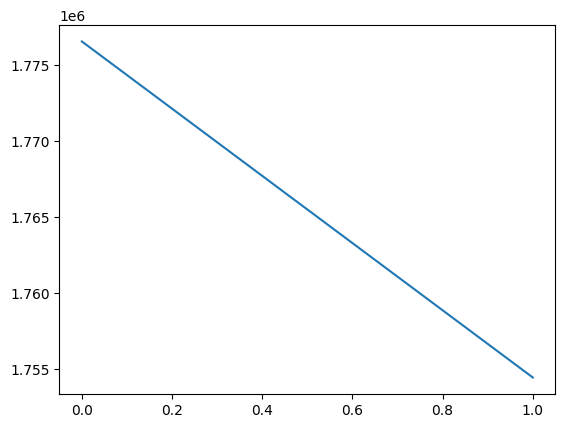

In [79]:
plt.plot(loss_dynamics_t)

Could use even smaller learning rate, but whatever.

## Results

The experiment has no known hardware ground-truth channel, so it must not report true-vs-estimated diamond norms. The checks below compare the fitted distribution directly against the observed counts; they are in-sample goodness-of-fit diagnostics, not an independent validation.

In [57]:
dim

2

In [58]:
def fitted_probabilities(solver: QGOptSolver) -> np.ndarray:
    channels = solver._get_estimated_channels()
    solver.eval_estimated.gates = unwrap_dict(channels)
    return np.stack([np.abs(solver.eval_estimated.evaluate(all_bitstrings, str(i)).numpy())
                     for i in range(len(enriched_data))])

model_probabilities = fitted_probabilities(QC_t)
observed_probabilities = np.stack([counts.numpy() / entry['shots']
                                   for counts, entry in zip(compressed_results, enriched_data)])
total_variation = 0.5 * np.abs(model_probabilities - observed_probabilities).sum(axis=1)
print(f'Mean in-sample total-variation distance: {total_variation.mean():.4f}')
print(f'Median in-sample total-variation distance: {np.median(total_variation):.4f}')

Mean in-sample total-variation distance: 0.4164
Median in-sample total-variation distance: 0.4028


### Plotting norms

In [62]:
norms_dict = norm_dict

In [63]:
from collections import defaultdict
HLINES = defaultdict(list)

for label in QC_t.hidden_gates_dict:
    sublist = QC_t.hidden_gates_dict[label]
    for idx, gate in enumerate(sublist):
        if label == 'Noise2':
            HLINES[label].append(util.diamond_norm_2q(gate, default_pure_channels[label], dim))
        #elif label == 'M':
            #HLINES[label].append(util.get_povm_dist(gate, default_pure_channels[label], dim))
        elif label == 'Noise':
            HLINES[label].append(util.diamond_norm_1q(gate, default_pure_channels[label], dim))
            
COLORS = plt.cm.tab20.colors

In [64]:
def plot_diamond_norms(ax1, ax2):
    colors_idx = [0, 0]
    
    for key in norms_dict.keys():
        label, idx, norm_type = key

        if label in ['Noise2']:#['Noise', 'Noise2']:
            #if (label == 'CX' and idx == 1) or (label == 'Noise-CX' and idx == 1):
                #continue
                
            if norm_type == 'i':
                ax1.plot(np.abs(norms_dict[label, idx, norm_type]),
                         label=f'{label}{idx}',
                         color=COLORS[colors_idx[0]])
                ax1.axhline(y=HLINES[label][idx],
                            color=COLORS[colors_idx[0]],
                            linestyle=':')
                colors_idx[0] += 1

            else:
                ax2.plot(np.abs(norms_dict[label, idx, norm_type]),
                         label=f'{label}{idx}',
                         color=COLORS[colors_idx[1]])
                colors_idx[1] += 1
            
    ax1.set_title('Diamond norm(ideal, est)', {"size":18})
    ax1.set_xlabel('Algorithm iteration number', {"size":16})

    ax2.set_title('Diamond norm(true, est)', {"size":18})
    ax2.set_xlabel('Algorithm iteration number', {"size":16})

    ax1.legend(prop={'size': 14})
    ax2.legend(prop={'size': 14})
        
        # ax.set_ylim(0.92, 0.98)
        
def plot_povm_norms(ax1, ax2):
    colors_idx = [0, 0]
    
    for key in norms_dict.keys():
        label, idx, norm_type = key

        if label == 'M':
            if norm_type == 'i':
                ax1.plot(np.abs(norms_dict[label, idx, norm_type]),
                         label=f'{label}{idx}',
                         color=COLORS[colors_idx[0]])
                ax1.axhline(y=HLINES[label][idx],
                            color=COLORS[colors_idx[0]],
                            linestyle=':')
                colors_idx[0] += 1

            else:
                ax2.plot(np.abs(norms_dict[label, idx, norm_type]),
                         label=f'{label}{idx}',
                         color=COLORS[colors_idx[1]])
                colors_idx[1] += 1
            
    ax1.set_title('POVM norm(ideal, est)', {"size":18})
    ax1.set_xlabel('Algorithm iteration number', {"size":16})

    ax2.set_title('POVM norm(true, est)', {"size":18})
    ax2.set_xlabel('Algorithm iteration number', {"size":16})

    ax1.legend(prop={'size': 14})
    ax2.legend(prop={'size': 14})
        
        # ax.set_ylim(0.92, 0.98)

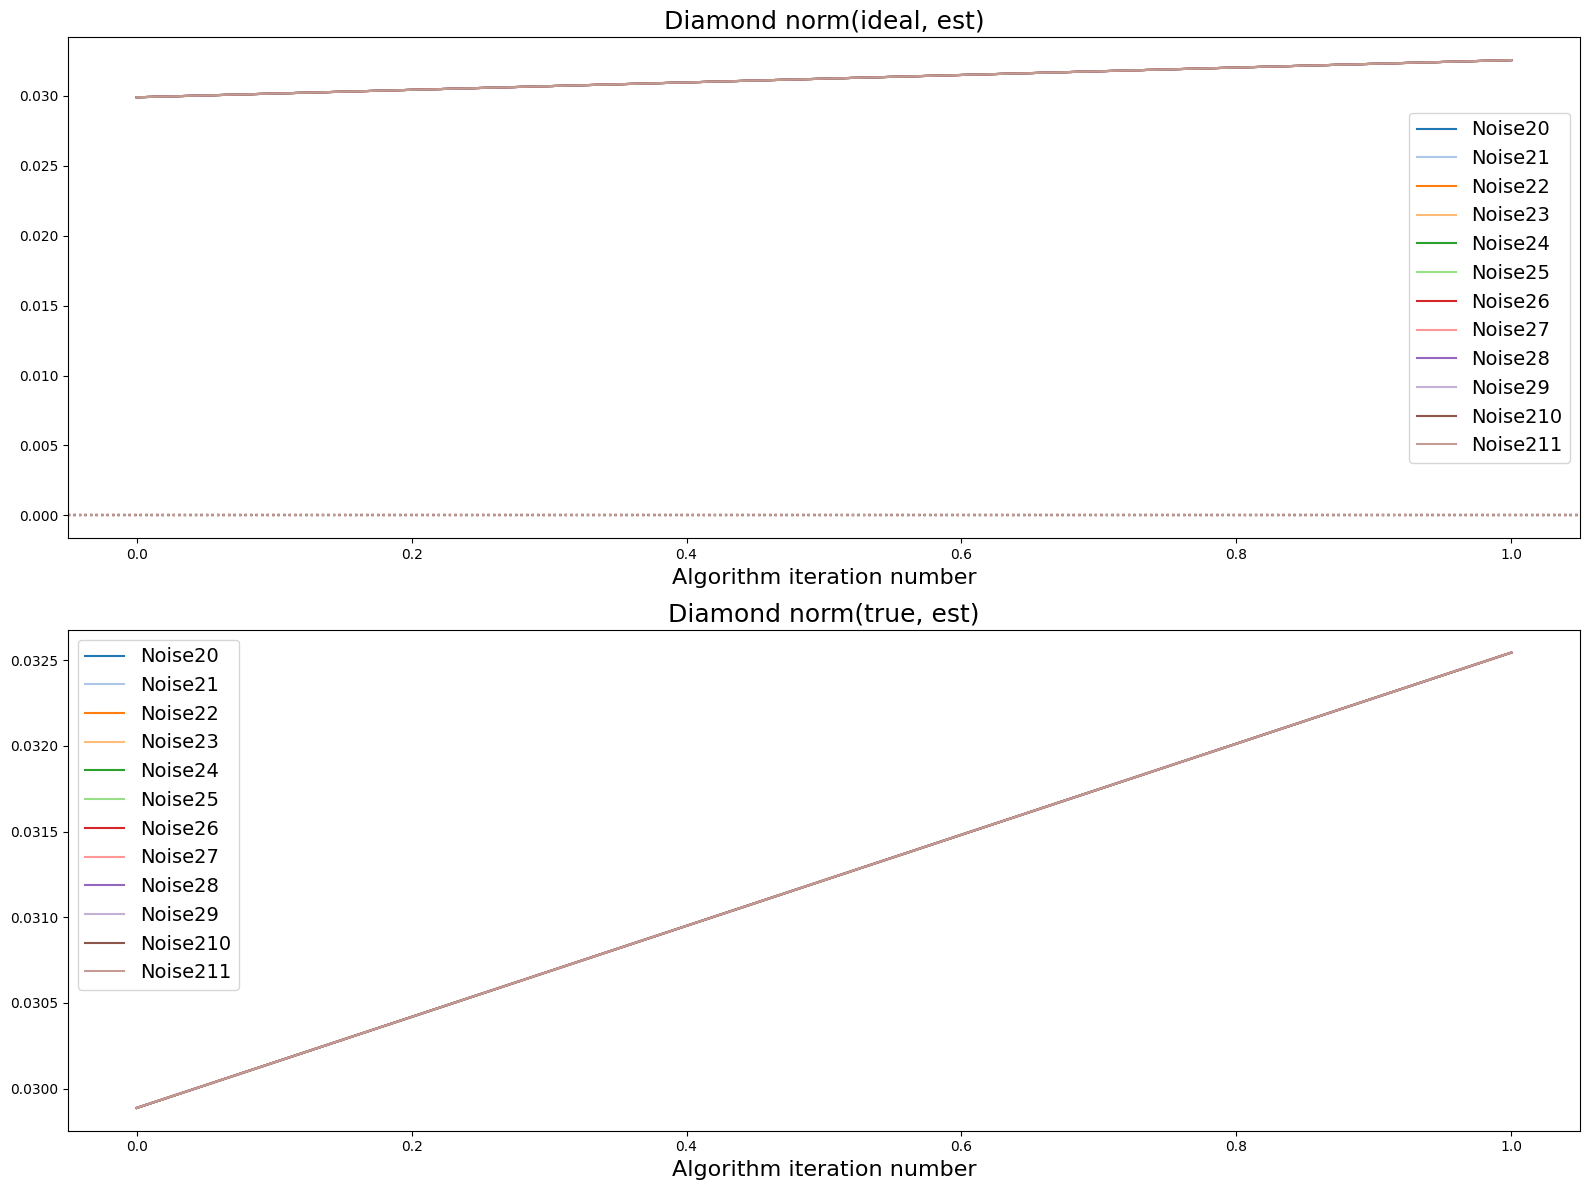

In [65]:
fig, axarr = plt.subplots(2, 1, figsize=(16, 12))
#fig, axarr = plt.subplots(2, figsize=(16, 12))
ax1, ax2 = [a for a in axarr]
#ax1, ax2 = [a for a in axarr]
plot_diamond_norms(ax1, ax2)
#plot_povm_norms(ax3, ax4)
fig.tight_layout()
plt.show()

In [99]:
estim_Noise = c_util.convert_params_to_channel(qgo.manifolds.real_to_complex(QC_t.estimated_gates_dict['Noise']), dim)

In [ ]:
estim_Noise

In [ ]:
final_Noise = tf.reduce_mean(estim_Noise, axis=0)
final_Noise

In [101]:
estim_Noise2 = c_util.convert_params_to_channel(qgo.manifolds.real_to_complex(QC_t.estimated_gates_dict['Noise2']), dim)

In [ ]:
final_Noise2 = tf.reduce_mean(estim_Noise2, axis=0)
final_Noise2

In [ ]:
noise_set = set()
for c in circs:
    for gate in c:
        if gate.find('Noise2') != -1:
            noise_set.add(gate)
print(noise_set)